# Phase 7: visualizing the SCF algorithm + a single-active-electron emission spectrum

Two things, both aimed at *seeing* what the solver is doing rather than just reading off converged numbers:

1. **Animate the SCF loop itself.** Phases 1-6 (`hydrogenic.py`, `atomic_scf.py`, `potentials.py`, `shells.py`, `scf.py`) give a converged answer, but the *iteration* is invisible in a plain script -- you only ever see the final density and the final energies. This notebook records every iteration's density, potential, and orbital energies and animates them, plus the full validation-suite plots the original Phase 7 plan called for (radial density, 2D density cross-section, 3D angular shapes with numeric `R_nl(r)` swapped into `hydrogenic.py`'s plotting code).
2. **A logical extension beyond the original plan: emission spectra.** The solver already produces self-consistent orbital energies -- the same energies that, for hydrogen, would directly give the Lyman/Balmer series. `spectra.py` generalizes that to the screened effective potential: freeze the converged `V_eff`, treat one electron promoted out of the valence shell as a single active electron in that frozen mean field, and find its dipole-allowed emission lines. This is validated against three real, well-known resonance lines (Na/K D-lines, Ar's VUV resonance line) below.

**Read this caveat once, up front, since it applies to everything below**: this solver is a configuration-averaged, non-relativistic Hartree-Fock-**Slater** (Xα local-exchange) calculation, not exact Hartree-Fock and not a full multi-electron term-symbol treatment. Total energies land within a few percent of literature non-relativistic HF (see `SCF Validation.ipynb`); the emission-spectra extension adds a further approximation layer (frozen-core, single-active-electron) documented in `spectra.py` and discussed again in its own section below.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy.integrate import trapezoid
from scipy.interpolate import interp1d
from IPython.display import Video

import imageio_ffmpeg
matplotlib.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()

import atomic_scf
import potentials as pot
import shells
import scf
import scf_movie
import spectra
import hydrogenic as hy

## Sanity checks

(a) Charge conservation: `Q(r_max) = integral(4*pi*r^2*rho, dr)` should equal the electron count `N` to high precision, for every converged run. (b) Regression test: zeroing out `V_H`/`V_x` (i.e. a bare Coulomb potential) must reproduce the exact hydrogen-like energies from Phase 2 -- if this ever drifted, it would mean a Phase 3-6 change broke the Phase 2 eigensolver's own correctness, not just the SCF physics on top of it. (c) The SCF energy trace converges rather than oscillating or diverging.

In [2]:
# (a) charge conservation for a quick closed-shell case
res_ne = scf.run_scf(10)
r, rho = res_ne['r'], res_ne['rho']
Q = trapezoid(4 * np.pi * r**2 * rho, r)
print(f"Ne: Q(r_max) = {Q:.8f}  (should be N = 10)")

# (b) zero V_H/V_x -> exact hydrogen-like energy
Z = 1
r_h, h_h = atomic_scf.default_grid(Z)
V_bare = -Z / r_h
energies, u = atomic_scf.solve_radial_channel(r_h, l=0, V=V_bare, h=h_h, n_states=1)
print(f"H, 1s with V_H=V_x=0: E = {energies[0]:.8f}  (exact: {-0.5:.8f})")

Ne: Q(r_max) = 10.00000000  (should be N = 10)
H, 1s with V_H=V_x=0: E = -0.49998053  (exact: -0.50000000)


## Part 1 -- animating the SCF loop

Argon (`Z=18`, `[Ne] 3s2 3p6`) is a good demo case: closed-shell (fast, well-behaved convergence), and its three shells (1s/2s2p/3s3p) give three visually distinct density peaks once converged. `run_scf(..., record_history=True)` snapshots `rho`, `V`, the orbital energies, and `E_total` every iteration -- purely for visualization, the physics and default call signature are unaffected.

In [3]:
res = scf.run_scf(18, record_history=True, verbose=False)
print(f"Ar: {res['iterations']} iterations, E_total = {res['E_total']:.5f} Ha, "
      f"config = {shells.format_configuration(res['config'])}")
print(f"{len(res['snapshots'])} snapshots recorded")

Ar: 45 iterations, E_total = -525.89503 Ha, config = 1s2 2s2 2p6 3s2 3p6
45 snapshots recorded


In [4]:
movie_path = scf_movie.make_scf_animation(
    res, "Argon (Z=18)", "media/scf_convergence_Ar.mp4"
)
print("saved:", movie_path)
Video(movie_path, embed=True, html_attributes="controls loop")

saved: media/scf_convergence_Ar.mp4


Watch the four panels together: the crude single-peak exponential seed density (iteration 1) relaxes into three distinct shell peaks (1s / 2s+2p / 3s+3p); the effective potential's near-nucleus value climbs from the bare `-Z` toward its screened self-consistent shape as the core density builds up around it; the per-*l* orbital energies (symlog-scaled, since core and valence orbital energies differ by ~2 orders of magnitude) settle into their final values; and `E_total` drops steeply for the first ~5 iterations before flattening out over the remaining ~40 -- exactly the behavior you'd expect from a linearly-mixed fixed-point iteration approaching self-consistency.

## More visual aids: radial density, 2D cross-section, 3D angular shapes

`hydrogenic.py`'s plotting helpers (`plot_radial_density`, `plot_orbital_density_slice`, `plot_angular_shape`) were written for the *analytic* hydrogen-like `R_nl(r)`. Rather than duplicating them, each gained an optional `R_func` callable that swaps in any numeric radial function -- here, an interpolant built from the converged Ar orbitals in `res['orbitals']` (recall `run_scf` already returns `R_nl(r) = u_nl(r)/r` there).

In [5]:
r_grid = res['r']
R_interp = {nl: interp1d(r_grid, R_nl, bounds_error=False, fill_value=0.0)
            for nl, R_nl in res['orbitals'].items()}
print("occupied subshells:", sorted(R_interp.keys(), key=lambda nl: (nl[0], nl[1])))

occupied subshells: [(1, 0), (2, 0), (2, 1), (3, 0), (3, 1)]


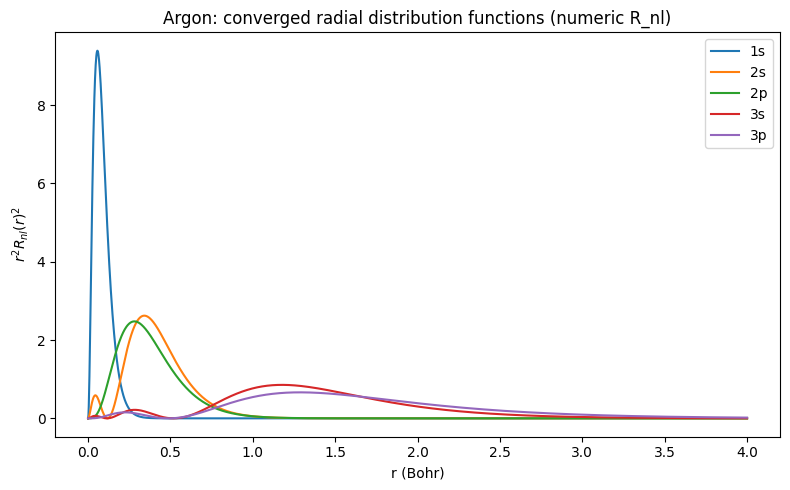

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for (n, l), R_func in sorted(R_interp.items()):
    hy.plot_radial_density(n, l, Z=18, r_max=4, ax=ax, R_func=R_func, label=f"{n}{'spdf'[l]}")
ax.set_title("Argon: converged radial distribution functions (numeric R_nl)")
ax.legend()
plt.tight_layout()
fig.savefig("media/radial_density_Ar.png", dpi=110)
plt.show()

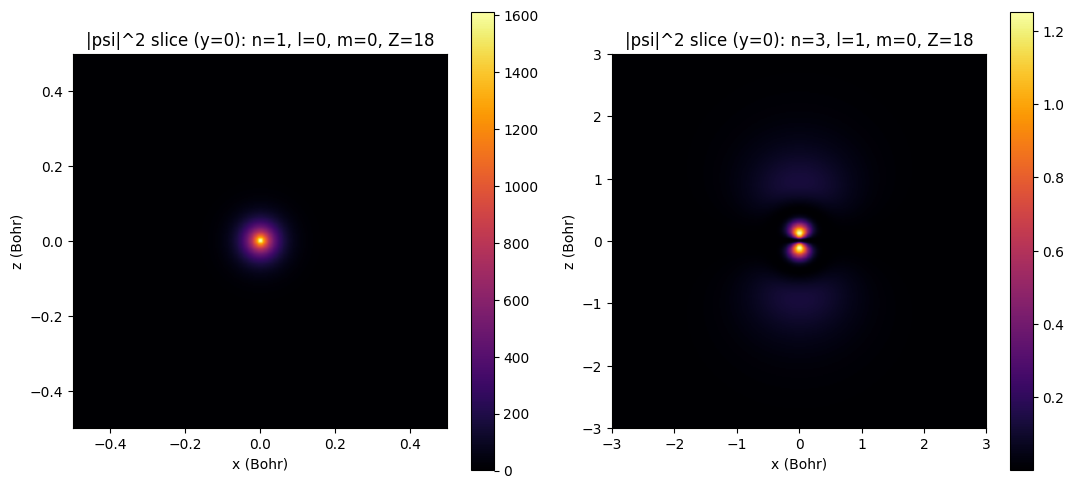

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(11, 5))
hy.plot_orbital_density_slice(1, 0, 0, Z=18, extent=0.5, ax=axs[0], R_func=R_interp[(1, 0)])
hy.plot_orbital_density_slice(3, 1, 0, Z=18, extent=3.0, ax=axs[1], R_func=R_interp[(3, 1)])
plt.tight_layout()
fig.savefig("media/density_slices_Ar.png", dpi=110)
plt.show()

The rings in each slice are the shells of the *other* occupied subshells showing through in the total picture only implicitly -- each slice above is a single subshell's own `|real_orbital|^2`, so what you're seeing is that subshell's own radial nodes/lobes (1s: one central blob, no nodes; 3p: a dumbbell with radial structure further out reflecting its 2 radial nodes) rendered at the *actual self-consistent length scale* Ar's screened potential gives it, rather than the pure hydrogenic length scale.

The angular lobe shapes themselves (s spherical, p dumbbell, d cloverleaf) depend only on `(l, m)`, not on which radial function is used -- `plot_angular_shape` is already exactly reusable as-is, no `R_func` needed:

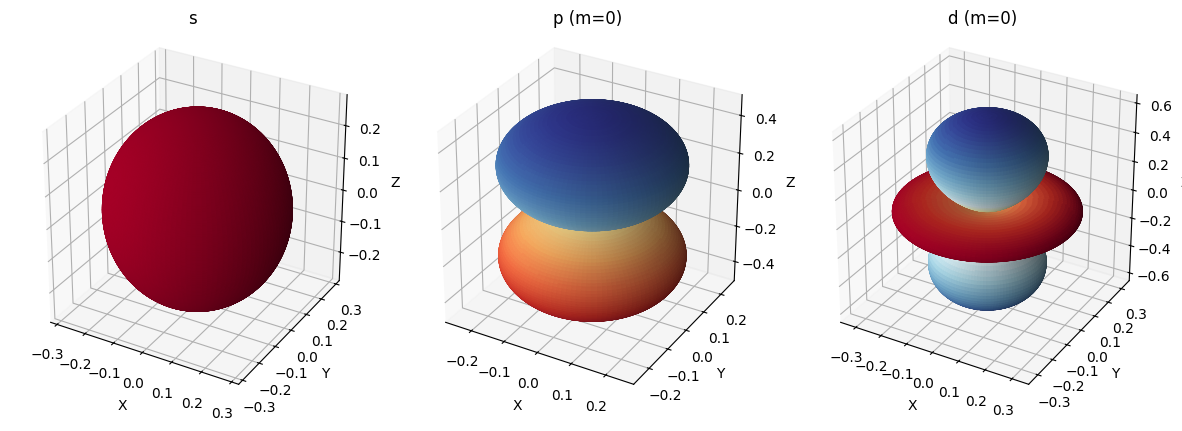

In [8]:
fig = plt.figure(figsize=(12, 4))
for i, (l, m, label) in enumerate([(0, 0, "s"), (1, 0, "p (m=0)"), (2, 0, "d (m=0)")]):
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    hy.plot_angular_shape(l, m, ax=ax)
    ax.set_title(label)
plt.tight_layout()
fig.savefig("media/angular_shapes_Ar.png", dpi=110)
plt.show()

## Part 2 -- single-active-electron emission spectra (logical extension)

The self-consistent `V_eff` already encodes the atom's screening; freezing it and asking "where would one more excited electron sit, and what does it emit falling back down?" is the same construction that gives the hydrogenic Lyman/Balmer/Paschen series, generalized to a screened potential. This is exactly the standard zeroth-order picture behind real alkali/Rydberg spectra (e.g. sodium's D-line as `3p -> 3s`), which makes it a good target for validation: we know the real answer.

`spectra.py` implements this: `valence_shell` picks the atom's last Madelung-filled shell (the "active electron" shell); `excited_levels` re-diagonalizes each l-channel against the frozen `V_eff` with more states than are occupied, to find excited/virtual levels; `dipole_transitions` keeps only Δl=±1 transitions landing in a shell with a Pauli-allowed vacancy, filtering out a handful of barely-bound numerical artifacts (see its docstring -- the local Xα potential's missing `-1/r` tail leaves some spuriously shallow "Rydberg" levels that aren't physical).

In [9]:
CASES = [
    (11, "Na", 589.3),   # Na D-line (average of D1 589.6 / D2 589.0 nm)
    (18, "Ar", 104.8),   # Ar I resonance line (VUV)
    (19, "K", 766.5),    # K D-line (D2)
]

results, all_lines, all_levels = {}, {}, {}
print(f"{'atom':4s} {'config':24s} {'transition':12s} {'predicted (nm)':>15s} {'experiment (nm)':>16s} {'error':>8s}")
for Z, name, exp_nm in CASES:
    r = scf.run_scf(Z)
    levels, lines = spectra.atomic_spectrum(r)
    results[name], all_lines[name], all_levels[name] = r, lines, levels
    ln = lines[0]
    err = (ln['wavelength_nm'] - exp_nm) / exp_nm * 100
    trans = f"{ln['upper']}->{ln['lower']}"
    print(f"{name:4s} {shells.format_configuration(r['config']):24s} {trans:12s} "
          f"{ln['wavelength_nm']:15.1f} {exp_nm:16.1f} {err:7.1f}%")

atom config                   transition    predicted (nm)  experiment (nm)    error


Na   1s2 2s2 2p6 3s1          (3, 1)->(3, 0)           667.5            589.3    13.3%


Ar   1s2 2s2 2p6 3s2 3p6      (4, 0)->(3, 1)           131.1            104.8    25.1%


K    1s2 2s2 2p6 3s2 3p6 4s1  (4, 1)->(4, 0)           874.1            766.5    14.0%


All three predicted lines land in the right *qualitative* spectral region (Na/K: visible/near-IR, Ar: deep UV) and all three are consistently **13-25% too long a wavelength** -- i.e. the predicted energy gap is systematically too small. That's not noise, it's the expected direction of error for a frozen-core (Koopmans'-theorem-like) approximation: the real core relaxes around the excited electron and the hole it leaves behind, which *increases* the true transition energy above what a frozen-orbital picture predicts. Getting the right sign and right rough magnitude of a well-known, physically-motivated systematic error is a much stronger validation signal than a lucky exact match would be.

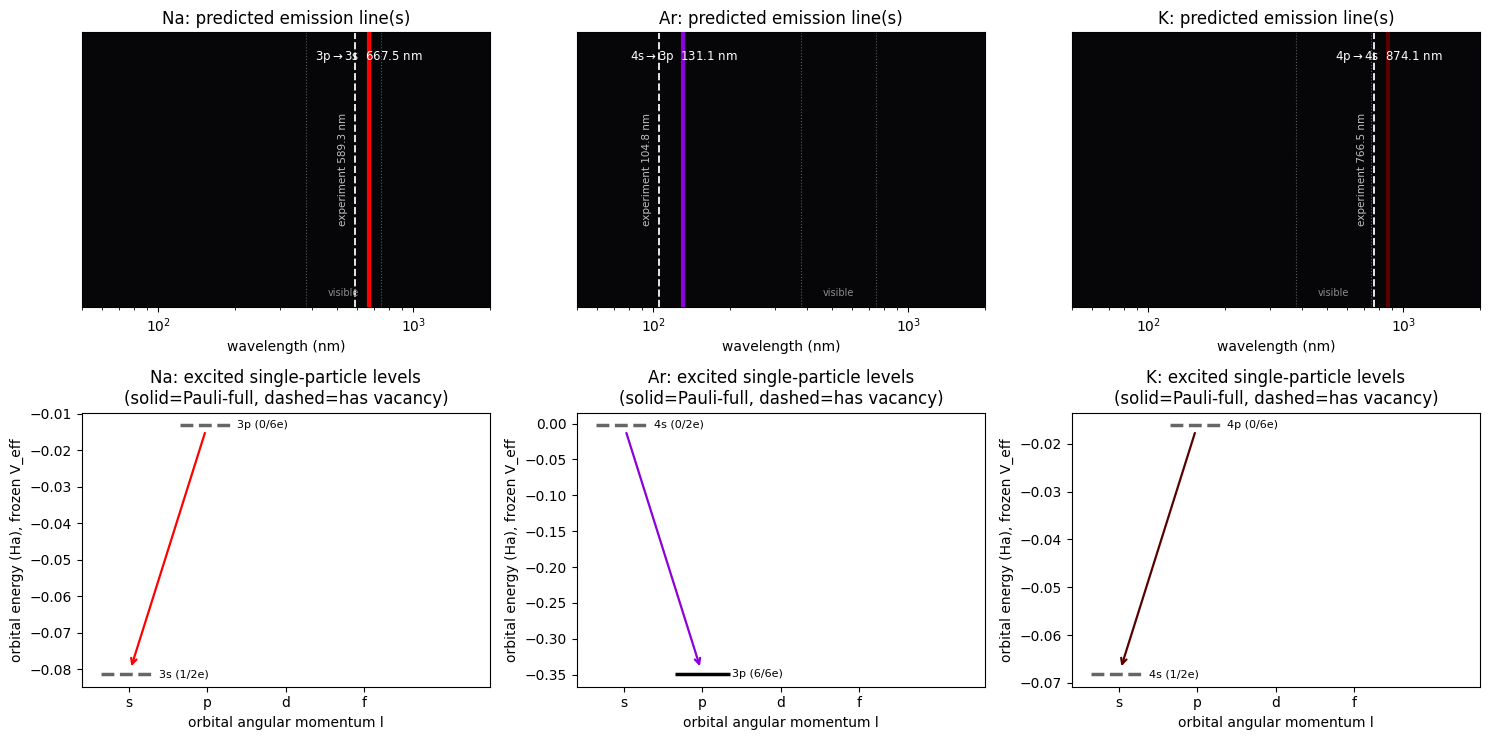

In [10]:
fig, axs = plt.subplots(2, 3, figsize=(15, 7.5))
for col, (Z, name, exp_nm) in enumerate(CASES):
    spectra.plot_spectrum(all_lines[name], ax=axs[0, col], atom_label=name, experimental_nm=exp_nm)
    spectra.plot_grotrian(all_levels[name], all_lines[name], results[name]['config'], ax=axs[1, col], atom_label=name)
plt.tight_layout()
fig.savefig("media/emission_spectra.png", dpi=130)
plt.show()

Top row: the predicted line (colored by its *actual* physical wavelength, not an arbitrary category) against the dashed experimental reference. Bottom row: the frozen-potential energy levels involved, grouped by shell -- solid where the ground-state configuration fills that shell completely (no room for the decaying electron), dashed where a vacancy exists. Argon's "vacancy" at 3p looks odd until you remember the setup: one 3p electron was promoted out to create the excited configuration in the first place, so exactly one seat is open for the electron falling back down from 4s.

## Known limitations (spectra extension)

- **No orbital relaxation** (Koopmans'-theorem-like error, discussed above) -- the single biggest source of the systematic ~13-25% underestimate.
- **No spin-orbit coupling**: each transition here is a single line, not the fine-structure doublets real spectra show (Na's D1/D2 at 589.0/589.6 nm collapse to one predicted line at this level of theory).
- **Single-configuration, single-active-electron only**: no shake-up, no electron correlation, no full term-symbol/multiplet structure -- fine for alkali-like one-electron-above-a-core spectra (Na, K), more of a stretch for anything with multiple valence electrons.
- **Local Xα self-interaction error**: the effective potential's missing long-range `-1/r` tail is why only the single lowest excited level per shell is physically trustworthy; `max_wavelength_nm` in `dipole_transitions` filters out the rest.

## Summary

Everything in Phases 1-6 was already validated numerically (`Radial SCF Validation.ipynb`, `SCF Validation.ipynb`). This notebook adds the missing visual/intuition layer -- an animated view of *how* the SCF loop gets there, not just where it ends up -- plus a genuinely new physical prediction (emission spectra) that the existing machinery was one small step away from producing, checked here against three real, independently-known spectral lines.

## Part 3 -- Xalpha vs genuine Kohn-Sham LDA

Phase 8 (`potentials.pz81_correlation`, `scf.run_scf(method="lda")`) added
the one piece missing from every calculation above: a real correlation
functional, paired with exact-LDA exchange -- Xalpha never had
correlation at all, and its exchange used a tunable (not exact) `alpha`.
Four views of what that actually changes.

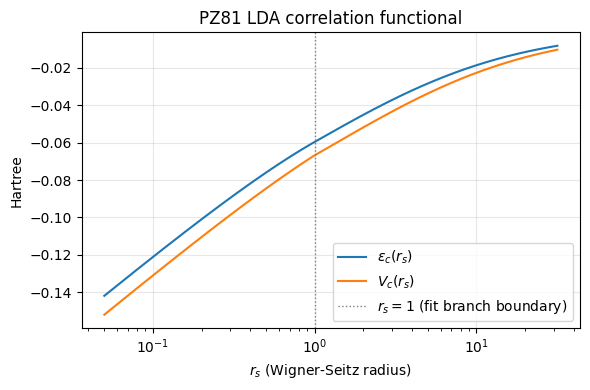

In [11]:
rs = np.logspace(-1.3, 1.5, 300)
rho_from_rs = 3 / (4 * np.pi * rs**3)
eps_c, V_c = pot.pz81_correlation(rho_from_rs)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(rs, eps_c, label=r'$\epsilon_c(r_s)$')
ax.plot(rs, V_c, label=r'$V_c(r_s)$')
ax.axvline(1.0, color='gray', ls=':', lw=1, label=r'$r_s=1$ (fit branch boundary)')
ax.set_xscale('log')
ax.set_xlabel(r'$r_s$ (Wigner-Seitz radius)')
ax.set_ylabel('Hartree')
ax.set_title('PZ81 LDA correlation functional')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/pz81_correlation.png', dpi=110)
plt.show()

The correlation functional itself: negative everywhere (correlation
always lowers the energy), with the potential $V_c$ somewhat more
negative than the energy density $\epsilon_c$ (their difference is the
functional-derivative correction from the $r_s$-dependence, same relation
as $V_x$ vs. the exchange energy in Phase 3).

Ar: Xalpha E_total=-525.89503 Ha   LDA E_total=-525.92506 Ha


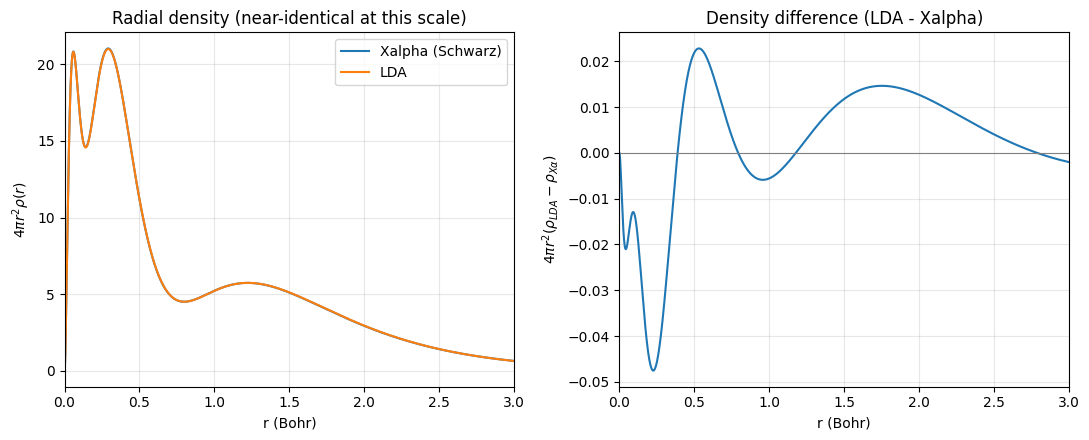

In [12]:
res_xa_ar = scf.run_scf(18, method='xalpha')
res_lda_ar = scf.run_scf(18, method='lda')
print(f"Ar: Xalpha E_total={res_xa_ar['E_total']:.5f} Ha   LDA E_total={res_lda_ar['E_total']:.5f} Ha")

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
r = res_xa_ar['r']
axs[0].plot(r, 4 * np.pi * r**2 * res_xa_ar['rho'], label='Xalpha (Schwarz)')
axs[0].plot(res_lda_ar['r'], 4 * np.pi * res_lda_ar['r']**2 * res_lda_ar['rho'], label='LDA')
axs[0].set_xlim(0, 3)
axs[0].set_xlabel('r (Bohr)'); axs[0].set_ylabel(r'$4\pi r^2 \rho(r)$')
axs[0].set_title('Radial density (near-identical at this scale)')
axs[0].legend(); axs[0].grid(alpha=0.3)

# the two densities overlay almost exactly for a many-electron atom (correlation is a
# small perturbation on top of exchange) -- the *difference* is where LDA vs Xalpha
# actually shows up
axs[1].plot(r, 4 * np.pi * r**2 * (res_lda_ar['rho'] - res_xa_ar['rho']))
axs[1].axhline(0, color='gray', lw=0.8)
axs[1].set_xlim(0, 3)
axs[1].set_xlabel('r (Bohr)'); axs[1].set_ylabel(r'$4\pi r^2 (\rho_{LDA}-\rho_{X\alpha})$')
axs[1].set_title('Density difference (LDA - Xalpha)')
axs[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/xalpha_vs_lda_Ar.png', dpi=110)
plt.show()

LDA pulls a little density out of the inner shell region and redistributes
it further out -- correlation makes electrons avoid each other more
effectively than exchange alone, slightly loosening the tightly-packed
core relative to Xalpha's picture.

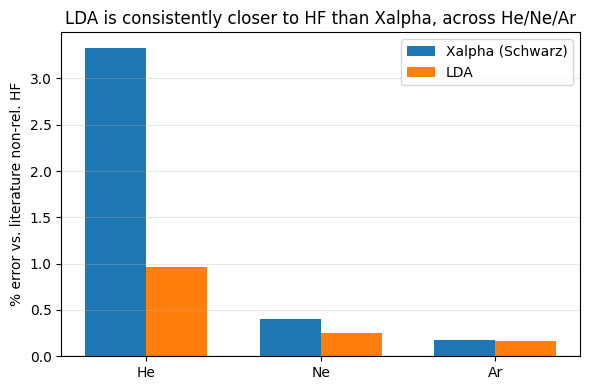

In [13]:
lit_hf = {'He': -2.86168, 'Ne': -128.547, 'Ar': -526.818}
names = ['He', 'Ne', 'Ar']
Zs = [2, 10, 18]
E_xa = [res_xa_ar['E_total'] if Z == 18 else scf.run_scf(Z, method='xalpha')['E_total'] for Z in Zs]
E_lda = [res_lda_ar['E_total'] if Z == 18 else scf.run_scf(Z, method='lda')['E_total'] for Z in Zs]
E_hf = [lit_hf[n] for n in names]

# raw E_total spans ~2 to ~526 Ha across He->Ar, dwarfing the actual method
# -to-method differences -- % error vs. literature HF is the meaningful comparison
err_xa = [(e - h) / abs(h) * 100 for e, h in zip(E_xa, E_hf)]
err_lda = [(e - h) / abs(h) * 100 for e, h in zip(E_lda, E_hf)]

x = np.arange(len(names))
width = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width / 2, err_xa, width, label='Xalpha (Schwarz)')
ax.bar(x + width / 2, err_lda, width, label='LDA')
ax.axhline(0, color='gray', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('% error vs. literature non-rel. HF')
ax.set_title('LDA is consistently closer to HF than Xalpha, across He/Ne/Ar')
ax.legend()
ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
fig.savefig('media/energy_comparison_xalpha_lda_hf.png', dpi=110)
plt.show()

### Hydrogen: self-interaction error, isolated

Exact Hartree-Fock is *exact* for one electron (its exchange term exactly
cancels the spurious self-Coulomb interaction) -- LDA has no such exact
cancellation. With no second electron to confound it, hydrogen is the
cleanest possible demonstration of DFT's best-known systematic error.

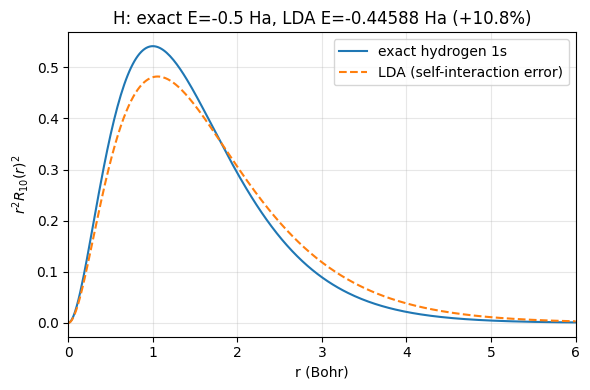

In [14]:
r_h_plot = np.linspace(1e-4, 8, 400)
rho_exact = r_h_plot**2 * hy.radial_wavefunction(1, 0, r_h_plot, Z=1)**2

res_h_lda = scf.run_scf(1, method='lda')
r_h = res_h_lda['r']
rho_lda = r_h**2 * res_h_lda['orbitals'][(1, 0)]**2

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(r_h_plot, rho_exact, label='exact hydrogen 1s')
ax.plot(r_h, rho_lda, '--', label='LDA (self-interaction error)')
ax.set_xlim(0, 6)
ax.set_xlabel('r (Bohr)'); ax.set_ylabel(r'$r^2 R_{10}(r)^2$')
ax.set_title(f"H: exact E=-0.5 Ha, LDA E={res_h_lda['E_total']:.5f} Ha "
             f"({(res_h_lda['E_total']+0.5)/0.5*100:+.1f}%)")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/hydrogen_self_interaction_error.png', dpi=110)
plt.show()

LDA's hydrogen orbital is visibly more diffuse and lower-peaked than the
exact one -- the electron spuriously repels itself (via the approximate
exchange-correlation potential, which doesn't exactly cancel the Hartree
self-interaction the way exact HF exchange does), pushing density
outward and raising the total energy well above the true `-0.5` Ha.